## Importando as Bibliotecas

In [51]:
# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Salvamento de modelos
# ================================
import joblib

# ================================
# Divisão dos dados
# ================================
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer
)

# ================================
# Validação e otimização
# ================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score

import time

print("Bibliotecas Importadas!!")

Bibliotecas Importadas!!


# 2. Leitura da base tratada

In [2]:
dados = pd.read_parquet("../data/gold/dataset_modelagem.parquet")
dados.head()

,ano,rede,sigla_uf,regiao,pib_per_capita,populacao_2022,area_km2,densidade_demografica,qtd_escolas_censo,prop_escolas_rurais,...,prop_escolas_biblioteca_leitura,prop_escolas_lab_informatica,prop_escolas_internet,prop_escolas_internet_aprendizagem,prop_escolas_banda_larga,prop_escolas_rampas_acessibilidade,media_alunos_turma_fund_ai,media_alunos_docente_fund_ai,media_prop_salas_climatizadas,alfabetizado
0,2023,Municipal,AM,Norte,17433.75,101883,7336.579,13.89,165,0.872727,...,0.132353,0.029412,0.705882,0.411765,0.541667,0.308824,19.188693,16.360779,0.642714,Não
1,2023,Municipal,AM,Norte,54985.63,2063689,11401.092,181.01,532,0.167293,...,0.531062,0.529058,0.969940,0.665331,0.878099,0.492986,25.931574,28.238906,0.920097,Não
2,2023,Municipal,AM,Norte,11569.04,20718,17472.779,1.19,97,0.969072,...,0.044944,0.000000,0.292135,0.224719,0.884615,0.056180,15.716064,14.607079,0.088443,Não
3,2023,Municipal,TO,Norte,28536.72,3334,2167.201,1.54,7,0.571429,...,0.200000,0.200000,1.000000,0.200000,0.400000,0.600000,17.472222,17.472222,0.200000,Não
4,2023,Municipal,MA,Nordeste,9325.56,25322,940.489,26.92,63,0.904762,...,0.153846,0.000000,0.948718,0.179487,1.000000,0.384615,25.611508,16.573413,0.198077,Não


# 3. Validação rápida dos Dados

In [3]:
print(f"Total de linhas: {dados.shape[0]}")
print(f"Total de colunas: {dados.shape[1]}")

Total de linhas: 57712
Total de colunas: 22


In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 57712 entries, 0 to 57711
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ano                                 57712 non-null  Int64  
 1   rede                                57712 non-null  string 
 2   sigla_uf                            57712 non-null  str    
 3   regiao                              57712 non-null  str    
 4   pib_per_capita                      57712 non-null  float64
 5   populacao_2022                      57712 non-null  int64  
 6   area_km2                            57712 non-null  float64
 7   densidade_demografica               57712 non-null  float64
 8   qtd_escolas_censo                   57712 non-null  Int64  
 9   prop_escolas_rurais                 57712 non-null  float64
 10  prop_escolas_agua_potavel           57712 non-null  float64
 11  prop_escolas_esgoto_rede            57712 non-null  

# 4. Definição da variável alvo

In [5]:
target = {
    'Não':0,
    'Sim': 1
}

dados['alfabetizado'] = dados['alfabetizado'].map(target)

In [6]:
dados['alfabetizado'].value_counts()

alfabetizado
0    29468
1    28244
Name: count, dtype: int64

# 5. Divisão dos dados em treino, validação e teste

O dataset foi dividido em três conjuntos independentes:

- **64% para treinamento:** utilizado para ajuste dos parâmetros do modelo;
- **16% para validação:** utilizado para comparação entre modelos e seleção de hiperparâmetros;
- **20% para teste:** reservado para a avaliação final do modelo selecionado.

A divisão foi realizada de forma estratificada pela variável alvo `alfabetizado`, preservando aproximadamente a mesma proporção entre as classes em todos os conjuntos.

Também foi definido `random_state=42` para garantir reprodutibilidade dos experimentos.

O conjunto de teste será mantido isolado durante as etapas de treinamento e seleção dos modelos, sendo utilizado apenas na avaliação final.

In [7]:
X = dados.drop('alfabetizado', axis=1)
y = dados['alfabetizado']

In [8]:
# 1º Divisão -> treino + validação e Teste
X_temp, X_teste, y_temp, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 2º Divisão -> treino e validação
X_treino, X_validacao, y_treino, y_validacao = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.2, random_state=42)

In [9]:
print(f"Treino -> {X_treino.shape[0]}")
print(f"Validação -> {X_validacao.shape[0]}")
print(f"Teste -> {X_teste.shape[0]}")

Treino -> 36935
Validação -> 9234
Teste -> 11543


# 6. Pré-processamento dos Dados

In [10]:
col_numericas = ['ano','pib_per_capita','populacao_2022','area_km2','densidade_demografica',
                 'qtd_escolas_censo','prop_escolas_rurais','prop_escolas_agua_potavel','prop_escolas_esgoto_rede','prop_escolas_biblioteca_leitura',
                 'prop_escolas_lab_informatica','prop_escolas_internet','prop_escolas_internet_aprendizagem','prop_escolas_banda_larga',
                 'prop_escolas_rampas_acessibilidade','media_alunos_turma_fund_ai','media_alunos_docente_fund_ai','media_prop_salas_climatizadas']

col_categoricas = ['rede', 'sigla_uf', 'regiao']

In [11]:
pipeline_numerico = Pipeline(
    steps=[
        # imputer(median) -> valores faltantes coloca a mediana
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [12]:
pipeline_categorico = Pipeline(
    steps=[
        # imputer(most_frequent) -> valores faltantes coloca o mais frequente da coluna
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop='first', handle_unknown="ignore",sparse_output=False))
    ]
)

In [13]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, col_numericas),
        ("cat", pipeline_categorico, col_categoricas)
    ]
)

X_treino_tratado = preprocessador.fit_transform(X_treino)
X_validacao_tratado = preprocessador.transform(X_validacao)
X_teste_tratado = preprocessador.transform(X_teste)

In [14]:
num_cols = list(col_numericas)
cat_cols = preprocessador.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(col_categoricas).tolist()

X_Treino = pd.DataFrame(X_treino_tratado, columns=num_cols + cat_cols)
X_Validacao = pd.DataFrame(X_validacao_tratado, columns=num_cols + cat_cols)
X_Teste = pd.DataFrame(X_teste_tratado, columns=num_cols + cat_cols)

In [15]:
X_treino.head()

,ano,rede,sigla_uf,regiao,pib_per_capita,populacao_2022,area_km2,densidade_demografica,qtd_escolas_censo,prop_escolas_rurais,...,prop_escolas_esgoto_rede,prop_escolas_biblioteca_leitura,prop_escolas_lab_informatica,prop_escolas_internet,prop_escolas_internet_aprendizagem,prop_escolas_banda_larga,prop_escolas_rampas_acessibilidade,media_alunos_turma_fund_ai,media_alunos_docente_fund_ai,media_prop_salas_climatizadas
31225,2024,Estadual,SP,Sudeste,53985.47,393237,30.732,12795.69,70,0.000000,...,1.000000,0.650000,0.783333,0.983333,0.983333,0.949153,0.066667,26.869488,18.853641,0.003086
24432,2023,Municipal,MT,Centro-Oeste,60344.41,29403,5976.864,4.92,17,0.529412,...,0.333333,0.266667,0.000000,1.000000,0.733333,0.933333,0.800000,27.954376,29.398866,0.903571
37890,2024,Municipal,SC,Sul,82633.59,59035,230.393,256.24,47,0.319149,...,0.297872,0.191489,0.170213,1.000000,0.957447,1.000000,0.787234,21.434977,16.048971,0.957769
54376,2023,Estadual,SC,Sul,146768.52,52674,493.266,106.79,14,0.142857,...,0.666667,0.666667,0.166667,1.000000,0.666667,0.833333,0.583333,16.194805,11.428976,0.077858
24074,2023,Municipal,CE,Nordeste,9710.87,22753,411.586,55.28,19,0.736842,...,0.277778,0.500000,0.055556,1.000000,0.944444,0.944444,0.611111,18.204686,11.781476,0.428924


# 7. Aplicação do VarianceThreshold

Com o objetivo de reduzir a dimensionalidade do conjunto de dados e remover atributos com baixa variabilidade, foi aplicado o método `VarianceThreshold`.

O filtro foi configurado com `threshold=0.05`, mantendo apenas as features cuja variância fosse superior a esse valor.

Como as variáveis numéricas foram previamente padronizadas com `StandardScaler`, esse filtro tende a afetar principalmente as variáveis binárias geradas pelo One-Hot Encoding, especialmente categorias pouco representadas na amostra.

Após a aplicação do filtro:

- **Features originais:** 48
- **Features selecionadas:** 30
- **Features removidas:** 18

A redução obtida diminui a dimensionalidade do conjunto de dados antes da modelagem.

É importante destacar que o `VarianceThreshold` é um método não supervisionado, ou seja, ele avalia apenas a variabilidade das features e não considera sua relação com a variável alvo.

Por esse motivo, a utilidade dessa redução deverá ser confirmada posteriormente por meio do desempenho dos modelos no conjunto de validação.

In [33]:
selector_variance = VarianceThreshold(threshold=0.05)

X_treino_variance = selector_variance.fit_transform(X_Treino)
X_validacao_variance = selector_variance.transform(X_Validacao)
X_teste_variance = selector_variance.transform(X_Teste)

features_variance = X_Treino.columns[selector_variance.get_support()]

print(f"Features Originais -> {X_Treino.shape[1]}")
print(f"Features Selecionadas -> {len(features_variance)}")

print("\nFeatures Mantidas:")
print(features_variance.tolist())

Features Originais -> 48
Features Selecionadas -> 30

Features Mantidas:
['ano', 'pib_per_capita', 'populacao_2022', 'area_km2', 'densidade_demografica', 'qtd_escolas_censo', 'prop_escolas_rurais', 'prop_escolas_agua_potavel', 'prop_escolas_esgoto_rede', 'prop_escolas_biblioteca_leitura', 'prop_escolas_lab_informatica', 'prop_escolas_internet', 'prop_escolas_internet_aprendizagem', 'prop_escolas_banda_larga', 'prop_escolas_rampas_acessibilidade', 'media_alunos_turma_fund_ai', 'media_alunos_docente_fund_ai', 'media_prop_salas_climatizadas', 'rede_Municipal', 'sigla_uf_BA', 'sigla_uf_MG', 'sigla_uf_PR', 'sigla_uf_RJ', 'sigla_uf_RS', 'sigla_uf_SC', 'sigla_uf_SP', 'regiao_Nordeste', 'regiao_Norte', 'regiao_Sudeste', 'regiao_Sul']


# 8. Treinamento e comparação inicial dos Modelos

In [42]:
modelos_classificacao = {
    "Regressao Logistica": LogisticRegression(random_state=42, max_iter=3000),
    "Arvore de Decisao": DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300, max_depth=5),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    #"SVM": SVC(kernel="rbf", class_weight='balanced', probability=True, random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, max_depth=5, n_estimators= 300)
}

In [43]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino_variance, y_treino)
    pred = modelo.predict(X_validacao_variance)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_validacao, pred),
        "Precision_0": precision_score(y_validacao, pred, pos_label=0),
        "Precision_1": precision_score(y_validacao, pred, pos_label=1),
        "Recall_0": recall_score(y_validacao, pred, pos_label=0),
        "Recall_1": recall_score(y_validacao, pred, pos_label=1),
        "F1-score": f1_score(y_validacao, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="Recall_0", ascending=False)
resultados_df.round(3)

,Modelo,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1-score
4,XGBoost,0.602,0.605,0.599,0.639,0.564,0.581
3,KNN,0.567,0.574,0.559,0.589,0.544,0.551
2,Random Forest,0.591,0.603,0.580,0.584,0.599,0.589
0,Regressao Logistica,0.575,0.586,0.564,0.572,0.578,0.571
1,Arvore de Decisao,0.567,0.589,0.550,0.502,0.635,0.589


In [44]:
# Selecionando o top 3 modelos
for nome in["XGBoost", "KNN", "Random Forest"]:
    modelo = modelos_classificacao[nome]
    modelo.fit(X_treino_variance, y_treino)
    pred = modelo.predict(X_validacao_variance)

    print(f"\nModelo -> {nome}")
    print(classification_report(y_validacao, pred))


Modelo -> XGBoost
              precision    recall  f1-score   support

           0       0.60      0.64      0.62      4715
           1       0.60      0.56      0.58      4519

    accuracy                           0.60      9234
   macro avg       0.60      0.60      0.60      9234
weighted avg       0.60      0.60      0.60      9234


Modelo -> KNN
              precision    recall  f1-score   support

           0       0.57      0.59      0.58      4715
           1       0.56      0.54      0.55      4519

    accuracy                           0.57      9234
   macro avg       0.57      0.57      0.57      9234
weighted avg       0.57      0.57      0.57      9234


Modelo -> Random Forest
              precision    recall  f1-score   support

           0       0.60      0.58      0.59      4715
           1       0.58      0.60      0.59      4519

    accuracy                           0.59      9234
   macro avg       0.59      0.59      0.59      9234
weighted avg   

# 9. Otimização dos Hiperparâmetros

In [53]:
xgb_model = xgb.XGBClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
knn_model = KNeighborsClassifier()

In [54]:
# Params XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    # Regularização L1
    "reg_alpha": [0, 0.01, 0.1, 1],
    # Regularização L2
    "reg_lambda": [0.1, 1, 5, 10]
}
# Params Random Forest
param_dist_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}
# Parâmetros do KNN
param_dist_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [55]:
score_recall_0 = make_scorer(
    recall_score, pos_label=0
)

In [56]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring=score_recall_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring=score_recall_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=20,
    scoring=score_recall_0,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [57]:
# Treino XGB + time
inicio = time.perf_counter()
random_xgb.fit(X_treino_variance, y_treino)
tempo_xgb = time.perf_counter() - inicio

# Treino RF + time
inicio = time.perf_counter()
random_rf.fit(X_treino_variance, y_treino)
tempo_rf = time.perf_counter() - inicio

# Treino KNN + time
inicio = time.perf_counter()
random_knn.fit(X_treino_variance, y_treino)
tempo_knn = time.perf_counter() - inicio

print("XGBoost - melhores parâmetros:")
print(random_xgb.best_params_)
print()

print("Random Forest - melhores parâmetros:")
print(random_rf.best_params_)
print()

print("KNN - melhores parâmetros:")
print(random_knn.best_params_)
print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\tech-challenge-fase3-literacy-ml\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 16 candidates, totalling 80 fits
XGBoost - melhores parâmetros:
{'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

Random Forest - melhores parâmetros:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}

KNN - melhores parâmetros:
{'weights': 'distance', 'n_neighbors': 7, 'metric': 'manhattan'}



In [58]:
modelos_tunados = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "KNN Tunado": random_knn.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_validacao_variance)

    resultados_tuning.append({
      'Modelo': nome,
      'Acurácia': accuracy_score(y_validacao, pred),
      'Recall_0': recall_score(y_validacao, pred, pos_label=0),
      'Recall_1': recall_score(y_validacao, pred, pos_label=1),
      'Precision_0': precision_score(y_validacao, pred, pos_label=0),
      'Precision_1': precision_score(y_validacao, pred, pos_label=1),
      'F1-Score': f1_score(y_validacao, pred)
    })

resultados_tuning_df = pd.DataFrame(resultados_tuning).sort_values(by="Recall_0", ascending=False)

print(f"Tempo XGBoost: {tempo_xgb:.2f} segundos")
print(f"Tempo Random Forest: {tempo_rf:.2f} segundos")
print(f"Tempo KNN: {tempo_knn:.2f} segundos")
print()
resultados_tuning_df.round(4)

Tempo XGBoost: 45.62 segundos
Tempo Random Forest: 347.03 segundos
Tempo KNN: 92.53 segundos



,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1-Score
1,Random Forest Tunado,0.6034,0.6435,0.5616,0.6050,0.6016,0.5809
0,XGBoost Tunado,0.5841,0.6331,0.5331,0.5859,0.5820,0.5565
2,KNN Tunado,0.5718,0.6244,0.5169,0.5742,0.5688,0.5416


# 10. Análise gráfica dos modelos otimizados

In [59]:
modelo_xgb_final = random_xgb.best_estimator_
modelo_rf_final = random_rf.best_estimator_
modelo_knn_final = random_knn.best_estimator_

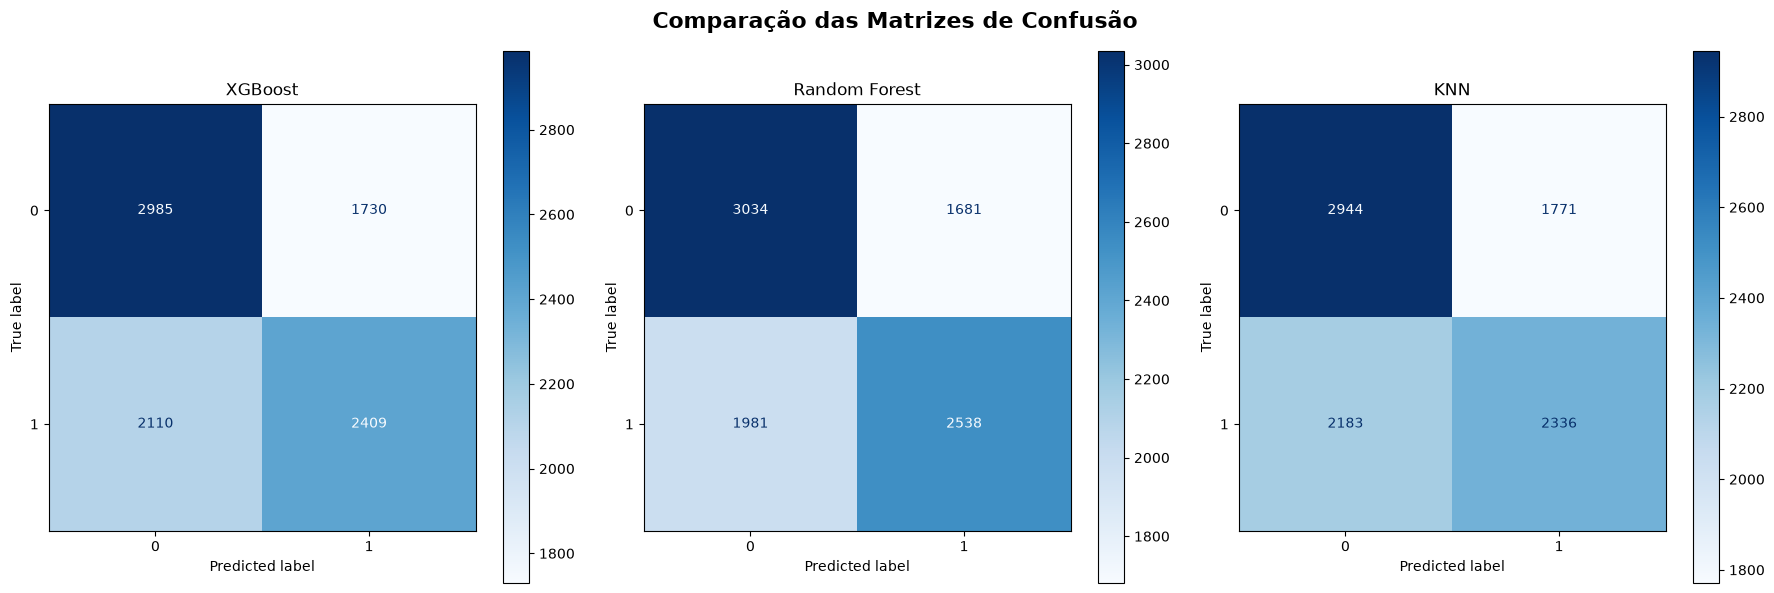

In [60]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
ConfusionMatrixDisplay.from_estimator(modelo_xgb_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[0], colorbar=True)
ax[0].set_title("XGBoost")

# Random Forest
ConfusionMatrixDisplay.from_estimator(modelo_rf_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[1], colorbar=True)
ax[1].set_title("Random Forest")

# KNN
ConfusionMatrixDisplay.from_estimator(modelo_knn_final, X_validacao_variance, y_validacao, cmap='Blues', ax=ax[2], colorbar=True)
ax[2].set_title("KNN")

# Titulo geral
plt.suptitle("Comparação das Matrizes de Confusão", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

TypeError: RocCurveDisplay.from_estimator() got an unexpected keyword argument 'color'

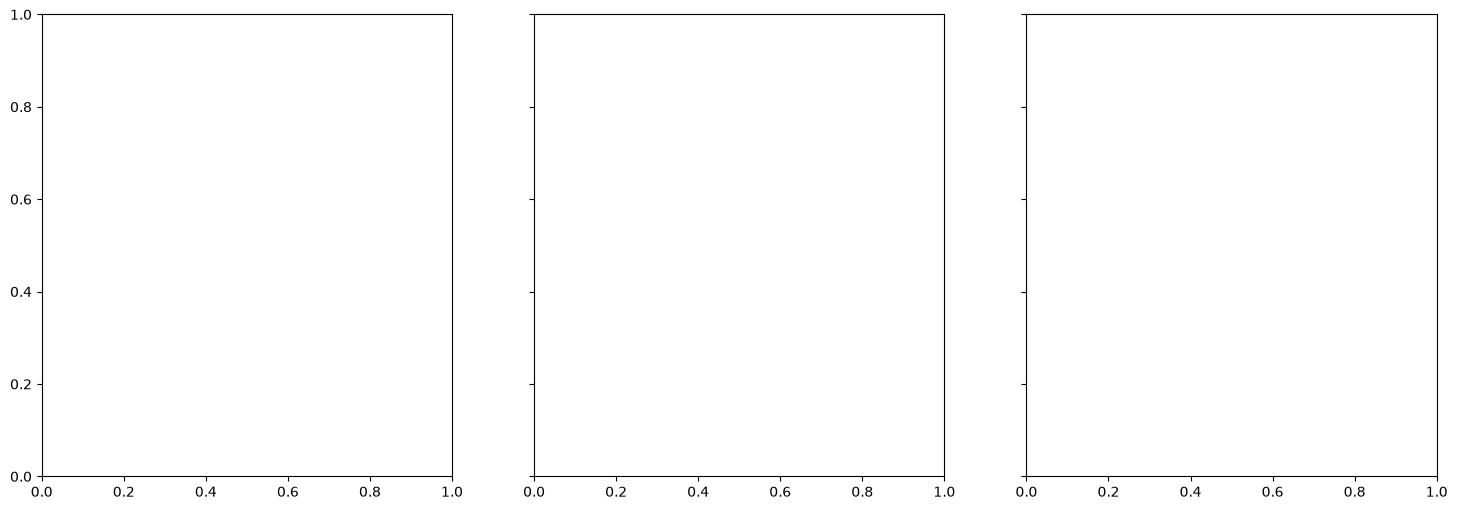

In [62]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# XGBoost
RocCurveDisplay.from_estimator(modelo_xgb_final, X_validacao_variance, y_validacao, ax=ax[0], color="#2E86DE")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[0].set_title("XGBoost", fontweight="bold")
ax[0].grid(alpha=0.3)

# Random Forest
RocCurveDisplay.from_estimator(modelo_rf_final, X_validacao_variance, y_validacao, ax=ax[1], color="#16A085")
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[1].set_title("Random Forest", fontweight="bold")
ax[1].grid(alpha=0.3)

# KNN 
RocCurveDisplay.from_estimator(modelo_knn_final, X_validacao_variance, y_validacao, ax=ax[2], color="#E67E22")
ax[2].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.8)
ax[2].set_title("KNN", fontweight="bold")
ax[2].grid(alpha=0.3)

plt.suptitle("Comparação das Curvas ROC", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()